# Mercado laboral mexicano: desempleo, sectores e informalidad (ENOE)

**Pregunta**: ¿Qué dice la ENOE sobre el desempleo, la composición sectorial y la informalidad en México en el trimestre más reciente (2025T1), y cómo se compara con los años recientes?

**Dataset**: Encuesta Nacional de Ocupación y Empleo (INEGI). El observatorio expone 101.5M microdatos y 76 mil indicadores agregados, con cobertura 2005T1–2025T1.

**Salvedades**: La serie cruza dos cambios metodológicos no triviales:

1. **Cambio de marco muestral en 2020T3** (post-Censo 2020).
2. **Redefinición del TCCO en 2020T1** (Tasa de Condiciones Críticas de Ocupación).

Más un gap documental en **2020T2** (etapa ETOE telefónica durante el confinamiento). El observatorio reporta indicadores con dominio uniforme de **15 años o más** en toda la serie.

## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from datos_mexico import DatosMexico

client = DatosMexico()

## 1. ¿Qué hay en el dataset?

El método `metadata()` resume cobertura, tablas y caveats metodológicos.

In [2]:
meta = client.enoe.metadata()
print(f"Fuente: {meta.fuente} — {meta.nombre}")
print(f"Periodicidad: {meta.periodicidad}")
print(f"Cobertura: {meta.cobertura_temporal}")
print(f"Indicadores agregados: {meta.n_indicadores}")
print(f"Entidades: {meta.n_entidades}")
print(f"Total microdatos: {meta.total_microdatos:,}")
print(f"Total agregados: {meta.total_agregados:,}")
print()
print("Caveats metodológicos publicados:")
for c in meta.caveats:
    print(f"  • {c.slug}: {c.titulo}")

Fuente: INEGI — Encuesta Nacional de Ocupación y Empleo
Periodicidad: Trimestral
Cobertura: 2005T1-2025T1 (80 trimestres con datos; gap documental en 2020T2)
Indicadores agregados: 13
Entidades: 32
Total microdatos: 101,512,667
Total agregados: 76,557

Caveats metodológicos publicados:
  • dominio_15_plus: Dominio operativo de la serie: población de 15 años o más
  • cambio_marco_2020T3: Cambio de marco muestral en 2020T3 (post-Censo 2020)
  • gap_2020T2_etoe: Gap 2020T2: ETOE telefónica sustituye al ENOE presencial (COVID-19)
  • til1_definicion_operativa: Tasa de Informalidad Laboral TIL1: 7 condiciones operativas
  • tcco_redefinicion_2020: TCCO (Condiciones Críticas de Ocupación): 3 condiciones operativas


## 2. Catálogo de los 13 indicadores agregados

Cada indicador tiene un slug estable, una fórmula y, cuando aplica, un caveat metodológico amarrado.

In [3]:
catalogo = client.enoe.indicadores()
for ind in catalogo.indicadores:
    print(f"{ind.slug:25s} {ind.nombre}  [{ind.unidad}]")

pob_15ymas                Población de 15 años o más  [personas]
pea_total                 Población Económicamente Activa (PEA)  [personas]
pnea_total                Población No Económicamente Activa (PNEA)  [personas]
ocupados_total            Población ocupada  [personas]
desocupados_total         Población desocupada  [personas]
subocupados_total         Población subocupada  [personas]
condcrit_total            Ocupados en condiciones críticas (TCCO)  [personas]
informales_total          Ocupados informales (TIL1 base)  [personas]
tasa_participacion        Tasa de Participación  [porcentaje]
tasa_desocupacion         Tasa de Desocupación  [porcentaje]
tasa_subocupacion         Tasa de Subocupación  [porcentaje]
tasa_informalidad_til1    Tasa de Informalidad Laboral (TIL1)  [porcentaje]
tasa_ocupacion_critica_tcco Tasa de Condiciones Críticas de Ocupación (TCCO)  [porcentaje]


## 3. Serie nacional histórica del desempleo

`serie_nacional` devuelve la trayectoria de un indicador a lo largo del tiempo. Aquí graficamos la tasa de desocupación 2005–2025 y marcamos los cortes metodológicos.

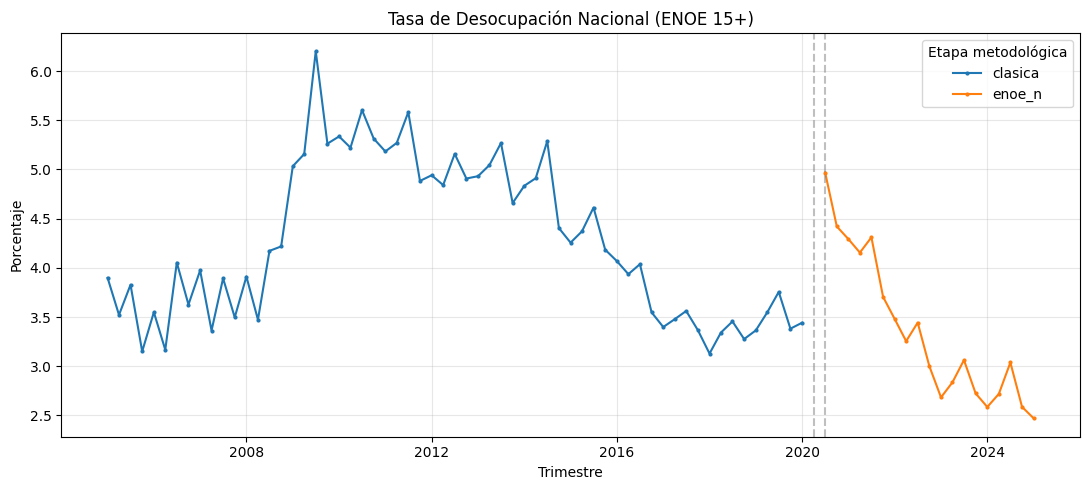

Cobertura: 80 trimestres entre 2005T1 y 2025T1


In [4]:
serie = client.enoe.serie_nacional(indicador="tasa_desocupacion")

df_serie = pd.DataFrame([{"periodo": p.periodo, "valor": p.valor, "etapa": p.etapa} for p in serie.datos])
df_serie["periodo_dt"] = pd.PeriodIndex(
    [f"{p[:4]}Q{p[5]}" for p in df_serie["periodo"]],
    freq="Q",
).to_timestamp()

fig, ax = plt.subplots(figsize=(11, 5))
for etapa, sub in df_serie.groupby("etapa"):
    ax.plot(sub["periodo_dt"], sub["valor"], marker="o", markersize=2, label=etapa)
ax.set_title("Tasa de Desocupación Nacional (ENOE 15+)")
ax.set_ylabel("Porcentaje")
ax.set_xlabel("Trimestre")
ax.axvline(pd.Timestamp("2020-04-01"), color="gray", linestyle="--", alpha=0.5)
ax.axvline(pd.Timestamp("2020-07-01"), color="gray", linestyle="--", alpha=0.5)
ax.legend(title="Etapa metodológica")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Cobertura: {serie.cobertura.n_observaciones} trimestres entre {serie.cobertura.desde} y {serie.cobertura.hasta}")

## 4. Snapshot 2025T1: los 13 indicadores en un vistazo

Mientras `serie_nacional` recorre un indicador a través del tiempo, `snapshot_nacional` toma todos los indicadores en un solo periodo.

In [5]:
snap = client.enoe.snapshot_nacional(periodo="2025T1")
df_snap = pd.DataFrame([
    {"indicador": i.indicador, "nombre": i.nombre, "unidad": i.unidad, "valor": i.valor}
    for i in snap.indicadores
])
df_snap

,indicador,nombre,unidad,valor
0,condcrit_total,Ocupados en condiciones críticas (TCCO),personas,1.974548e+07
1,desocupados_total,Población desocupada,personas,1.483994e+06
2,informales_total,Ocupados informales (TIL1 base),personas,3.210410e+07
3,ocupados_total,Población ocupada,personas,5.892149e+07
4,pea_total,Población Económicamente Activa (PEA),personas,6.007119e+07
5,pnea_total,Población No Económicamente Activa (PNEA),personas,4.144980e+07
6,pob_15ymas,Población de 15 años o más,personas,1.015273e+08
7,subocupados_total,Población subocupada,personas,3.901301e+06
8,tasa_desocupacion,Tasa de Desocupación,porcentaje,2.470392e+00
9,tasa_informalidad_til1,Tasa de Informalidad Laboral (TIL1),porcentaje,5.448622e+01


## 5. Ranking de entidades: ¿quiénes tienen el mayor desempleo?

`ranking` ordena las 32 entidades por un indicador en un periodo y devuelve los top-N. Este es exactamente el orden que INEGI publicó en su boletín 265/25.

In [6]:
ranking_top = client.enoe.ranking(
    periodo="2025T1", indicador="tasa_desocupacion", limit=5
)
ranking_bot = client.enoe.ranking(
    periodo="2025T1", indicador="tasa_desocupacion", orden="asc", limit=5
)

print("Top 5 con mayor desempleo (2025T1):")
for e in ranking_top.ranking:
    print(f"  {e.rank}. {e.entidad_nombre:30s} {e.valor:.2f}%")

print()
print("Top 5 con menor desempleo (2025T1):")
for e in ranking_bot.ranking:
    print(f"  {e.rank}. {e.entidad_nombre:30s} {e.valor:.2f}%")

Top 5 con mayor desempleo (2025T1):
  1. Tabasco                        4.97%
  2. Coahuila de Zaragoza           3.56%
  3. Durango                        3.46%
  4. Ciudad de México               3.45%
  5. Tamaulipas                     3.37%

Top 5 con menor desempleo (2025T1):
  1. Guerrero                       0.89%
  2. Morelos                        1.06%
  3. Michoacán de Ocampo            1.18%
  4. Yucatán                        1.54%
  5. Oaxaca                         1.65%


## 6. Composición sectorial nacional

`distribucion_sectorial_snapshot` agrega los ocupados en 12 sectores SCIAN. Útil para ver el peso de servicios diversos, agricultura, manufacturas, etc.

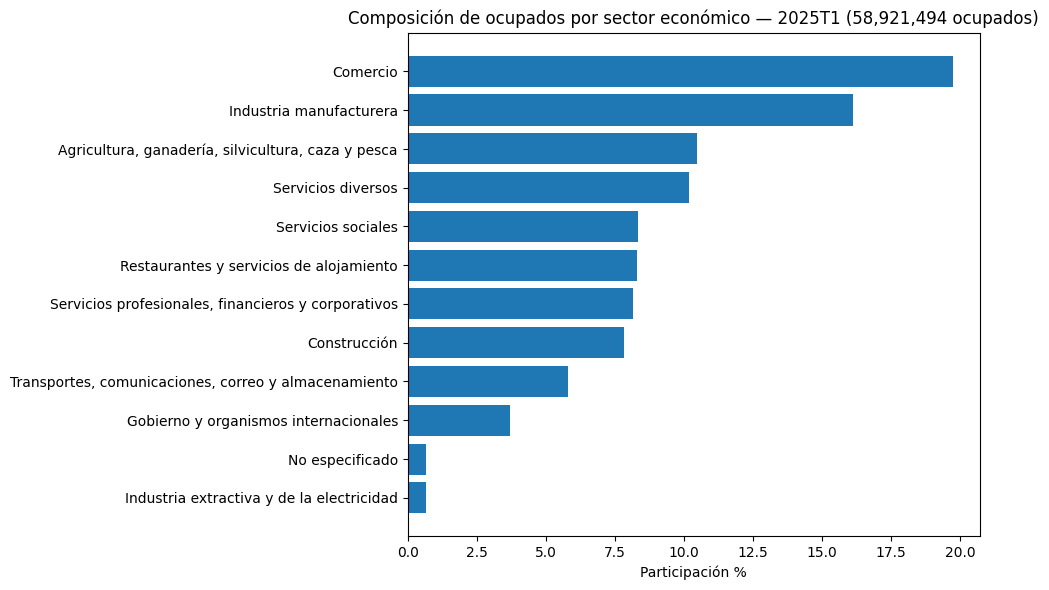

,sector,ocupados,pct
7,Comercio,11628131,19.7350
5,Industria manufacturera,9509132,16.1386
1,"Agricultura, ganadería, silvicultura, caza y p...",6170920,10.4731
2,Servicios diversos,5991207,10.1681
11,Servicios sociales,4902489,8.3204
8,Restaurantes y servicios de alojamiento,4883914,8.2888
10,"Servicios profesionales, financieros y corpora...",4816358,8.1742
6,Construcción,4619183,7.8396
9,"Transportes, comunicaciones, correo y almacena...",3419262,5.8031
3,Gobierno y organismos internacionales,2186005,3.7100


In [7]:
dist = client.enoe.distribucion_sectorial_snapshot(periodo="2025T1")
df_sec = pd.DataFrame([
    {"sector": r.sector_nombre, "ocupados": r.total_ocupados, "pct": r.participacion_porcentaje}
    for r in dist.distribucion
]).sort_values("ocupados", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_sec["sector"], df_sec["pct"])
ax.set_title(f"Composición de ocupados por sector económico — 2025T1 ({dist.total_ocupados_nivel:,} ocupados)")
ax.set_xlabel("Participación %")
fig.tight_layout()
plt.show()

df_sec.sort_values("pct", ascending=False)

## 7. Microdatos: muestra de CDMX 2025T1

Para análisis personalizados, descargamos microdatos sociodemográficos (`sdem`) de CDMX a un DataFrame con `microdatos_to_pandas`. El SDK páginas internamente; el helper materializa todo en memoria.

> Para volúmenes mayores, conviene usar `microdatos_iter` (generator) y procesar por chunks.

In [8]:
df = client.enoe.microdatos_to_pandas(
    "sdem",
    periodo="2025T1",
    entidad_clave="09",  # CDMX
    include_extras=False,  # solo columnas promovidas
    limit=2000,            # acotar la descarga para la demo
)
print(f"DataFrame: {len(df):,} filas × {len(df.columns)} columnas")
df.head()

DataFrame: 2,000 filas × 15 columnas


,periodo,etapa,cd_a,ent,con,v_sel,n_hog,n_ren,sex,eda,clase1,clase2,pos_ocu,rama_est2,fac_tri
0,2025T1,enoe_n,01,09,20293,75,1,1,1,74,1,1,2,8,2466
1,2025T1,enoe_n,01,09,20293,75,1,2,2,83,2,4,0,0,2466
2,2025T1,enoe_n,01,09,20293,77,1,1,1,31,1,1,1,9,2466
3,2025T1,enoe_n,01,09,20293,77,1,2,2,29,1,1,1,8,2466
4,2025T1,enoe_n,01,09,20293,79,1,1,1,50,1,1,1,8,2466


### Distribución de edad ponderada por factor de expansión

El `fac_tri` es el factor de expansión: cada fila representa `fac_tri` personas de CDMX 15+.

Personas 15+ representadas: 2,127,482


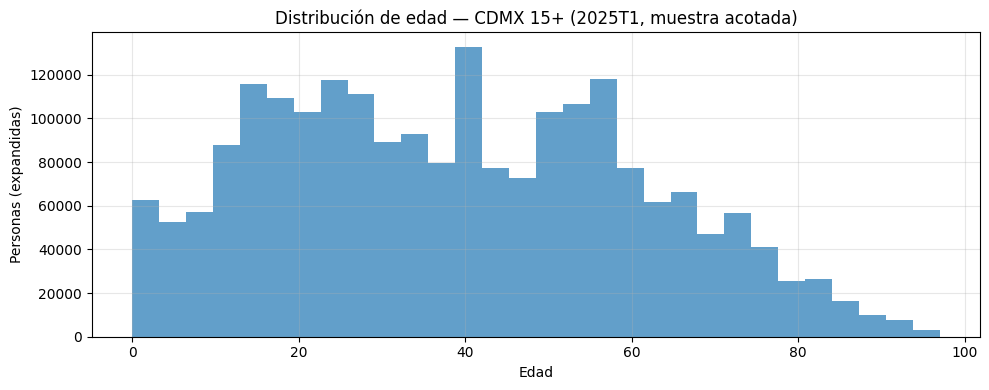

In [9]:
# Universo expandido de la muestra
print(f"Personas 15+ representadas: {df['fac_tri'].sum():,.0f}")

# Distribución de edad ponderada
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["eda"], bins=30, weights=df["fac_tri"], alpha=0.7)
ax.set_title("Distribución de edad — CDMX 15+ (2025T1, muestra acotada)")
ax.set_xlabel("Edad")
ax.set_ylabel("Personas (expandidas)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Cierre

El SDK reproduce al peso las cifras publicadas oficialmente por INEGI; el ranking de la sección 5 es exactamente el orden de la **comunicación 265/25** del INEGI sobre Indicadores de Ocupación y Empleo, primer trimestre 2025. Para validar:

```bash
DATOS_MEXICO_INTEGRATION_TESTS=1 pytest tests/test_enoe.py::test_integration_inegi_265_25_reproducible -v
```

Próximas extensiones del observatorio (Fase 4): indicadores por área metropolitana e indicadores anuales del cuestionario ampliado (ya provisionados en schema).

In [10]:
client.close()